<a href="https://colab.research.google.com/github/trupti2021/FirstGIT/blob/main/housePricePrediction3Dplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/AutogluonDrop/HousePrediction.csv")

In [3]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [4]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [5]:
df=df[['price', 'bedrooms', 'sqft_living']]

In [6]:
df.columns

Index(['price', 'bedrooms', 'sqft_living'], dtype='object')

In [12]:
X=df.drop('price',axis=1)
y=df['price']

In [13]:
X

,bedrooms,sqft_living
0,3.0,1340
1,5.0,3650
2,3.0,1930
3,3.0,2000
4,4.0,1940
...,...,...
4595,3.0,1510
4596,3.0,1460
4597,3.0,3010
4598,4.0,2090


In [14]:
df

,price,bedrooms,sqft_living
0,3.130000e+05,3.0,1340
1,2.384000e+06,5.0,3650
2,3.420000e+05,3.0,1930
3,4.200000e+05,3.0,2000
4,5.500000e+05,4.0,1940
...,...,...,...
4595,3.081667e+05,3.0,1510
4596,5.343333e+05,3.0,1460
4597,4.169042e+05,3.0,3010
4598,2.034000e+05,4.0,2090


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

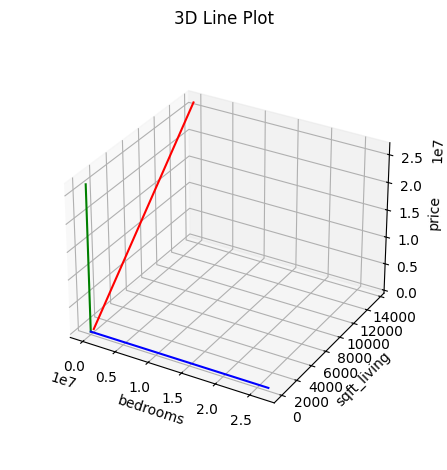

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.axes(projection='3d')

x = np.linspace(min(df['bedrooms']),max(df['bedrooms']))
y=np.linspace(min(df['sqft_living']),max(df['sqft_living']))
z=np.linspace(min(df['price']),max(df['price']))
#x = z * np.sin(25 * z)
#y = z * np.cos(25 * z)
#x=np.linspace(min(history.history['loss']),max(history.history['loss']),100)
#y=np.linspace(min(history.history['accuracy']),max(history.history['accuracy']),100)

ax.plot3D(x, y, z, 'red')
ax.plot3D(y, x, z, 'green')
ax.plot3D(z, x, y, 'blue')
ax.set_title('3D Line Plot')
ax.xaxis.set_label_text('bedrooms')
ax.yaxis.set_label_text('sqft_living')
ax.zaxis.set_label_text('price')
ax.set_zlabel('price')
ax.set_box_aspect(None, zoom=0.85) # Zoom out slightly
plt.tight_layout()

plt.show()